In [76]:
 !pip install -r requirements.txt -q


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [77]:
import pandas as pd

df = pd.read_csv("s&p_500_hist.csv")
df.head()

,date,tickers
0,1996-01-02,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
1,1996-01-03,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
2,1996-01-04,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
3,1996-01-10,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
4,1996-01-11,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."


In [78]:
df.shape

(2720, 2)

In [79]:
# Delimit date from september 13 2024 to  septemember 13 2026
START = "2020-09-13"
END = "2026-09-13"
BATCH = 100

In [80]:
mask = df["date"].between(START, END)
mask |= df["date"] == df.loc[df["date"] <= START, "date"].max()

In [81]:
tickers = sorted(set(df.loc[mask, "tickers"].str.split(",").explode().str.strip()))

In [82]:
len(tickers)

632

In [83]:
from pathlib import Path

import yfinance as yf


def download(tickers, start=START, end=END, batch=BATCH, cache=None, refresh=False):
    """Return a long DataFrame: date, ticker, open/high/low/close, volume.

    Results are cached to CSV: the first call hits Yahoo and saves, later calls
    read the file back. Pass refresh=True to force a re-download.
    """
    cache = Path(cache or f"prices_{start}_{end}.csv")
    if cache.exists() and not refresh:
        print(f"loading cached {cache}")
        return pd.read_csv(cache, parse_dates=["date"])

    frames = []
    for i in range(0, len(tickers), batch):
        chunk = tickers[i : i + batch]
        raw = yf.download(
            [t.replace(".", "-") for t in chunk],  # Yahoo uses BRK-B, not BRK.B
            start=start, end=end, auto_adjust=True,
            group_by="column", progress=False, threads=True,
        )
        if raw.empty:
            continue
        frames.append(raw.stack(level="Ticker", future_stack=True))
        print(f"  {i + len(chunk)}/{len(tickers)} tickers")

    out = pd.concat(frames).dropna(how="all").reset_index()
    out.columns = [c.lower() for c in out.columns]
    out = out.sort_values(["ticker", "date"]).reset_index(drop=True)

    out.to_csv(cache, index=False)
    print(f"saved {len(out):,} rows to {cache}")
    return out

In [84]:
prices = download(tickers)

$ANSS: possibly delisted; no timezone found
$ALXN: possibly delisted; no timezone found
$BK: possibly delisted; no timezone found
$ANTM: possibly delisted; no timezone found
$BLL: possibly delisted; no timezone found
$AFL: possibly delisted; no price data found  (1d 2020-09-13 -> 2026-09-13)
$ABMD: possibly delisted; no timezone found
$ABC: possibly delisted; no timezone found
$ATVI: possibly delisted; no timezone found

9 Failed downloads:
['ANSS', 'ALXN', 'BK', 'ANTM', 'BLL', 'ABMD', 'ABC', 'ATVI']: possibly delisted; no timezone found
['AFL']: possibly delisted; no price data found  (1d 2020-09-13 -> 2026-09-13)


  100/632 tickers


$COG: possibly delisted; no timezone found
$DISCA: possibly delisted; no timezone found
$DISH: possibly delisted; no timezone found
$CTXS: possibly delisted; no timezone found
$CERN: possibly delisted; no timezone found
$DISCK: possibly delisted; no timezone found
$DAY: possibly delisted; no timezone found
$CMA: possibly delisted; no timezone found
$CDAY: possibly delisted; no timezone found
$CTLT: possibly delisted; no timezone found
$DFS: possibly delisted; no timezone found
$CXO: possibly delisted; no timezone found
$CTRA: possibly delisted; no timezone found
$DRE: possibly delisted; no timezone found
$CTL: possibly delisted; no timezone found

15 Failed downloads:
['COG', 'DISCA', 'DISH', 'CTXS', 'CERN', 'DISCK', 'DAY', 'CMA', 'CDAY', 'CTLT', 'DFS', 'CXO', 'CTRA', 'DRE', 'CTL']: possibly delisted; no timezone found


  200/632 tickers


$FLIR: possibly delisted; no timezone found
$HFC: possibly delisted; no timezone found
$FRC: possibly delisted; no timezone found
$HOLX: possibly delisted; no timezone found
$HES: possibly delisted; no timezone found
$FLT: possibly delisted; no timezone found
$HBI: possibly delisted; no timezone found
$FBHS: possibly delisted; no timezone found
$FI: possibly delisted; no timezone found
$ETFC: possibly delisted; no timezone found
$GPS: possibly delisted; no timezone found

11 Failed downloads:
['FLIR', 'HFC', 'FRC', 'HOLX', 'HES', 'FLT', 'HBI', 'FBHS', 'FI', 'ETFC', 'GPS']: possibly delisted; no timezone found


...

  500/632 tickers


$TWTR: possibly delisted; no timezone found
$VAR: possibly delisted; no timezone found
$TIF: possibly delisted; no timezone found
$SEE: possibly delisted; no timezone found
$SATS: possibly delisted; no timezone found
$VIAC: possibly delisted; no timezone found
$SIVB: possibly delisted; no timezone found

7 Failed downloads:
['TWTR', 'VAR', 'TIF', 'SEE', 'SATS', 'VIAC', 'SIVB']: possibly delisted; no timezone found


  600/632 tickers


$WBA: possibly delisted; no timezone found
$WRK: possibly delisted; no timezone found
$XLNX: possibly delisted; no timezone found
$WLTW: possibly delisted; no timezone found

4 Failed downloads:
['WBA', 'WRK', 'XLNX', 'WLTW']: possibly delisted; no timezone found


  632/632 tickers
saved 834,682 rows to prices_2020-09-13_2026-09-13.csv


In [85]:
prices.head()

,date,ticker,adj close,close,high,low,open,volume
0,2020-09-14,A,NaN,95.353203,96.130075,94.921613,95.650527,1207700.0
1,2020-09-15,A,NaN,96.264336,96.868563,95.640923,95.640923,1053800.0
2,2020-09-16,A,NaN,95.832718,97.376861,94.067988,97.089137,1365000.0
3,2020-09-17,A,NaN,95.525833,96.350655,94.547560,95.190151,1246400.0
4,2020-09-18,A,NaN,95.314827,96.475331,94.432462,95.084646,2162400.0


In [86]:
prices.shape

(834682, 8)

In [89]:
import numpy as np

def plot(prices, tickers=None, metric="close", start=None, end=None,
         log=False, normalize=False, ax=None, **kwargs):
    """Plot one metric for every ticker on a single axes.

    log=True plots log values, matching what the cointegration test consumes:
    equal vertical distances are then equal *percentage* moves.
    normalize=True rebases each series to its first point, so names on very
    different scales stay comparable — to 100 on raw values, to 0 on logs.
    """
    import matplotlib.pyplot as plt

    wide = prices.pivot(index="date", columns="ticker", values=metric)
    if tickers is not None:
        wide = wide[list(tickers)]
    wide = wide.loc[start:end].dropna(axis=1, how="all")

    if log:
        wide = np.log(wide.where(wide > 0))       # volume can be 0; log(0) is -inf
    base = wide.ffill().bfill().iloc[0]
    if normalize:
        wide = (wide - base) * 100 if log else wide / base * 100

    if ax is None:
        _, ax = plt.subplots(figsize=(13, 7))
    wide.plot(ax=ax, linewidth=1, alpha=0.8, **kwargs)

    label = f"log {metric}" if log else metric
    if normalize:
        label += " (cumulative % log return)" if log else " (rebased to 100)"
    ax.set(xlabel="", ylabel=label,
           title=f"{wide.shape[1]} tickers — {label}, "
                 f"{wide.index.min():%Y-%m-%d} to {wide.index.max():%Y-%m-%d}")
    if wide.shape[1] <= 20:
        ax.legend(ncol=2, fontsize=8)
    else:
        ax.get_legend().remove()
    ax.margins(x=0)
    return ax

<Axes: title={'center': '570 tickers — log volume, 2025-01-02 to 2026-09-11'}, ylabel='log volume'>

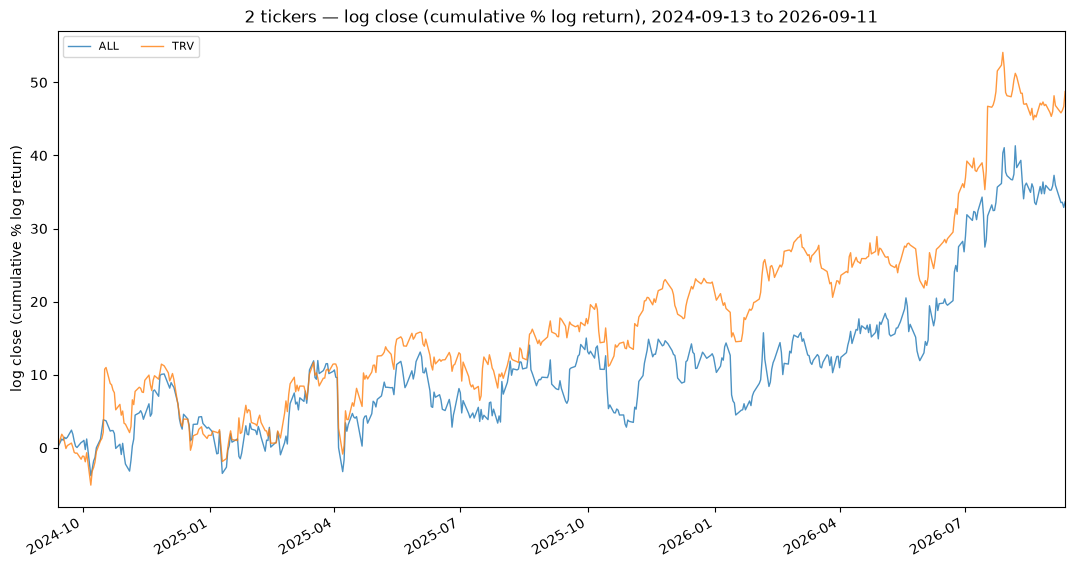

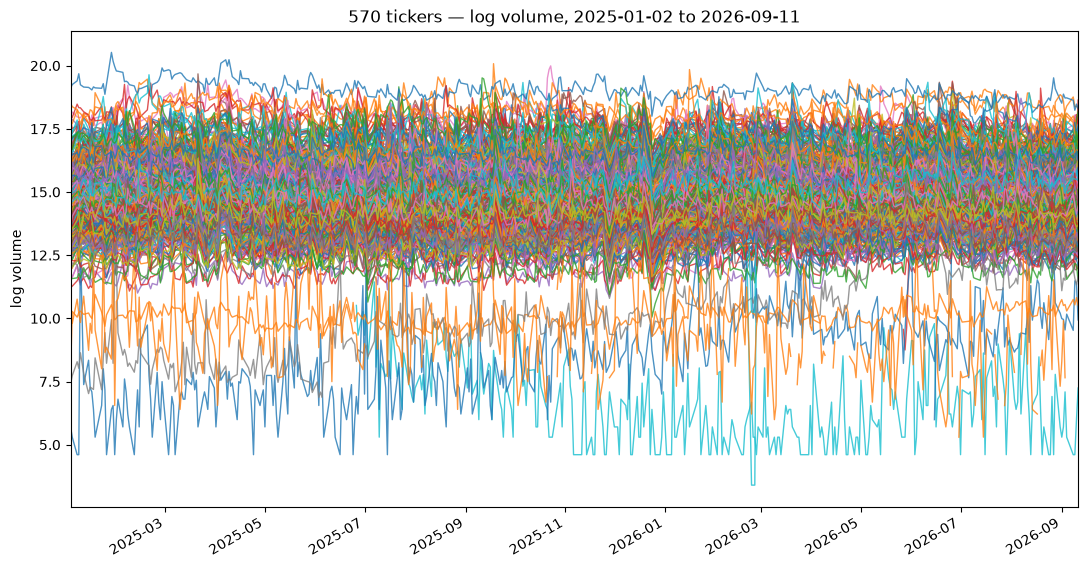

In [90]:
plot(prices, tickers=["ALL", "TRV"], start="2024-09-13", end="2026-09-13",
     log=True, normalize=True)
plot(prices, metric="volume", start="2025-01-01", log=True)   # all tickers, no legend

**Engle-Granger two-step cointegration test**

Two I(1) series are cointegrated if some linear combination of them is I(0).
Following [the Engle-Granger approach](https://medium.com/data-science/cointegration-popular-methods-1-2-the-engle-granger-approach-82b6d270ddf2):

0. Confirm both series are **I(1)** — a unit root in levels, stationary once differenced.
1. Regress one on the other by **OLS**: `y = a + b*x + e`. The slope `b` is the hedge ratio, the residual `e` is the spread.
2. Run an **ADF test on the residuals**. Reject the unit root => the spread is stationary => the pair is cointegrated.

One subtlety: the residuals are *estimated*, not observed, so OLS has already
minimised their variance and made them look more stationary than they really are.
Standard ADF p-values are therefore too optimistic. The correct null distribution
is MacKinnon's with `N=2` for a two-variable regression — that is what
`mackinnonp(..., N=2)` supplies below.

In [91]:
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.adfvalues import mackinnonp
from statsmodels.tsa.stattools import adfuller


def is_i1(series, alpha=0.05):
    """True if the series is I(1): unit root in levels, stationary in differences."""
    level = adfuller(series, regression="c", result_object=False)[1]
    diff = adfuller(series.diff().dropna(), regression="c", result_object=False)[1]
    return level > alpha and diff <= alpha


def half_life(spread):
    """Mean-reversion half-life of the spread, in trading days."""
    lag = spread.shift(1).dropna()
    delta = spread.diff().dropna()
    beta = sm.OLS(delta, sm.add_constant(lag.loc[delta.index])).fit().params.iloc[1]
    return -np.log(2) / beta if beta < 0 else np.inf


def engle_granger(y, x, check_i1=True, alpha=0.05):
    """Engle-Granger two-step test that y and x are cointegrated.

    y and x are price series (pass logs). Returns None if the I(1) precondition
    fails, otherwise a dict with the hedge ratio, the ADF statistic on the
    residuals, and the MacKinnon p-value for that statistic.
    """
    if check_i1 and not (is_i1(y) and is_i1(x)):
        return None

    # Step 1 - OLS: y = const + beta*x + spread
    fit = sm.OLS(y, sm.add_constant(x)).fit()
    spread = fit.resid

    # Step 2 - ADF on the residuals. regression="n" (no constant, no trend):
    # OLS has already forced the residuals to have zero mean.
    adf_stat, _, lags, nobs, _, _ = adfuller(
        spread, regression="n", autolag="AIC", result_object=False
    )

    # Residuals are estimated, so use MacKinnon's N=2 surface, not plain ADF.
    pvalue = mackinnonp(adf_stat, regression="c", N=2)

    return {
        "beta": fit.params.iloc[1],
        "const": fit.params.iloc[0],
        "adf_stat": adf_stat,
        "pvalue": pvalue,
        "lags": lags,
        "nobs": nobs,
        "cointegrated": pvalue < alpha,
        "spread": spread,
    }

In [92]:
import itertools


def screen_pairs(prices, metric="close", start=None, end=None,
                 corr_min=0.70, alpha=0.01, verbose=True):
    """Run Engle-Granger over every pair and return the cointegrated ones.

    corr_min prefilters on return correlation: testing all ~N^2/2 pairs is slow
    and, more importantly, inflates the false-positive count.
    """
    wide = prices.pivot(index="date", columns="ticker", values=metric)
    wide = wide.loc[start:end].dropna(axis=1)          # only full-history names
    log_px = np.log(wide)

    corr = log_px.diff().corr()
    candidates = [(a, b) for a, b in itertools.combinations(wide.columns, 2)
                  if corr.loc[a, b] >= corr_min]
    if verbose:
        print(f"{wide.shape[1]} tickers, {wide.shape[0]} days -> "
              f"{len(candidates)} candidate pairs at corr >= {corr_min}")

    rows = []
    for a, b in candidates:
        res = engle_granger(log_px[a], log_px[b], alpha=alpha)
        if res is None or not res["cointegrated"]:
            continue
        spread = res["spread"]
        rows.append({
            "a": a, "b": b,
            "pvalue": res["pvalue"], "adf_stat": res["adf_stat"],
            "beta": res["beta"], "corr": corr.loc[a, b],
            "half_life": half_life(spread),
            "zscore_now": (spread.iloc[-1] - spread.mean()) / spread.std(),
        })

    out = pd.DataFrame(rows).sort_values("pvalue").reset_index(drop=True)
    if verbose:
        print(f"{len(out)} cointegrated at p < {alpha} "
              f"(expected by chance alone: {len(candidates) * alpha:.0f})")
    return out

beta=0.974  ADF=-3.676  p=0.0197  cointegrated=True  half-life=39.1d


<Axes: title={'center': 'ALL vs TRV - Engle-Granger spread (OLS residual)'}, xlabel='date'>

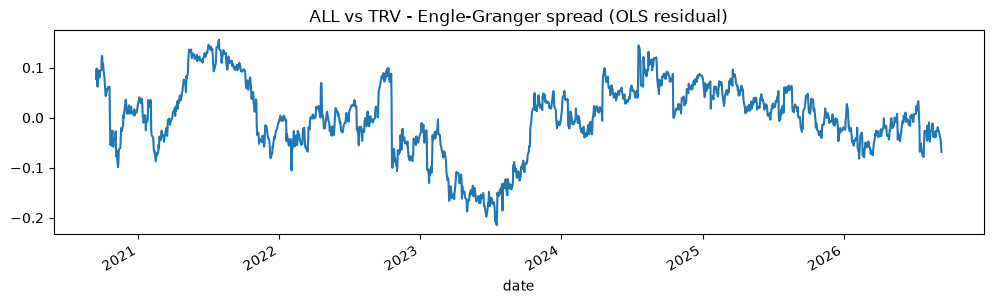

In [93]:
# One pair, step by step
wide = prices.pivot(index="date", columns="ticker", values="close").dropna(axis=1)

res = engle_granger(np.log(wide["ALL"]), np.log(wide["TRV"]))
print(f"beta={res['beta']:.3f}  ADF={res['adf_stat']:.3f}  p={res['pvalue']:.4f}  "
      f"cointegrated={res['cointegrated']}  half-life={half_life(res['spread']):.1f}d")

res["spread"].plot(figsize=(12, 3), title="ALL vs TRV - Engle-Granger spread (OLS residual)")

In [94]:
# All pairs
pairs = screen_pairs(prices, corr_min=0.70, alpha=0.01)
pairs.to_csv("cointegrated_pairs.csv", index=False)
pairs.head(25)

538 tickers, 1506 days -> 541 candidate pairs at corr >= 0.7
19 cointegrated at p < 0.01 (expected by chance alone: 5)


,a,b,pvalue,adf_stat,beta,corr,half_life,zscore_now
0,CMS,DUK,0.000195,-4.960187,0.767283,0.813179,24.815403,-1.646033
1,DTE,DUK,0.000817,-4.605564,0.887053,0.771004,25.189574,-0.621668
2,DUK,PPL,0.001338,-4.476565,0.950945,0.718733,28.037669,0.542735
3,FITB,PNC,0.001459,-4.453400,1.116710,0.867575,27.214188,-0.700767
4,TRGP,WMB,0.001575,-4.433013,1.539967,0.733691,53.310715,0.334352
5,CMS,DTE,0.001629,-4.423812,0.844955,0.831639,29.282152,-0.974998
6,DUK,NI,0.001667,-4.417710,0.590554,0.700875,29.089322,0.289722
7,HAL,NOV,0.002029,-4.364268,1.311865,0.807772,28.645505,-1.269614
8,HBAN,SYF,0.002133,-4.350504,0.536822,0.700575,34.037629,-0.223101
9,CMS,NI,0.003351,-4.224212,0.459788,0.751449,27.242137,-1.238209


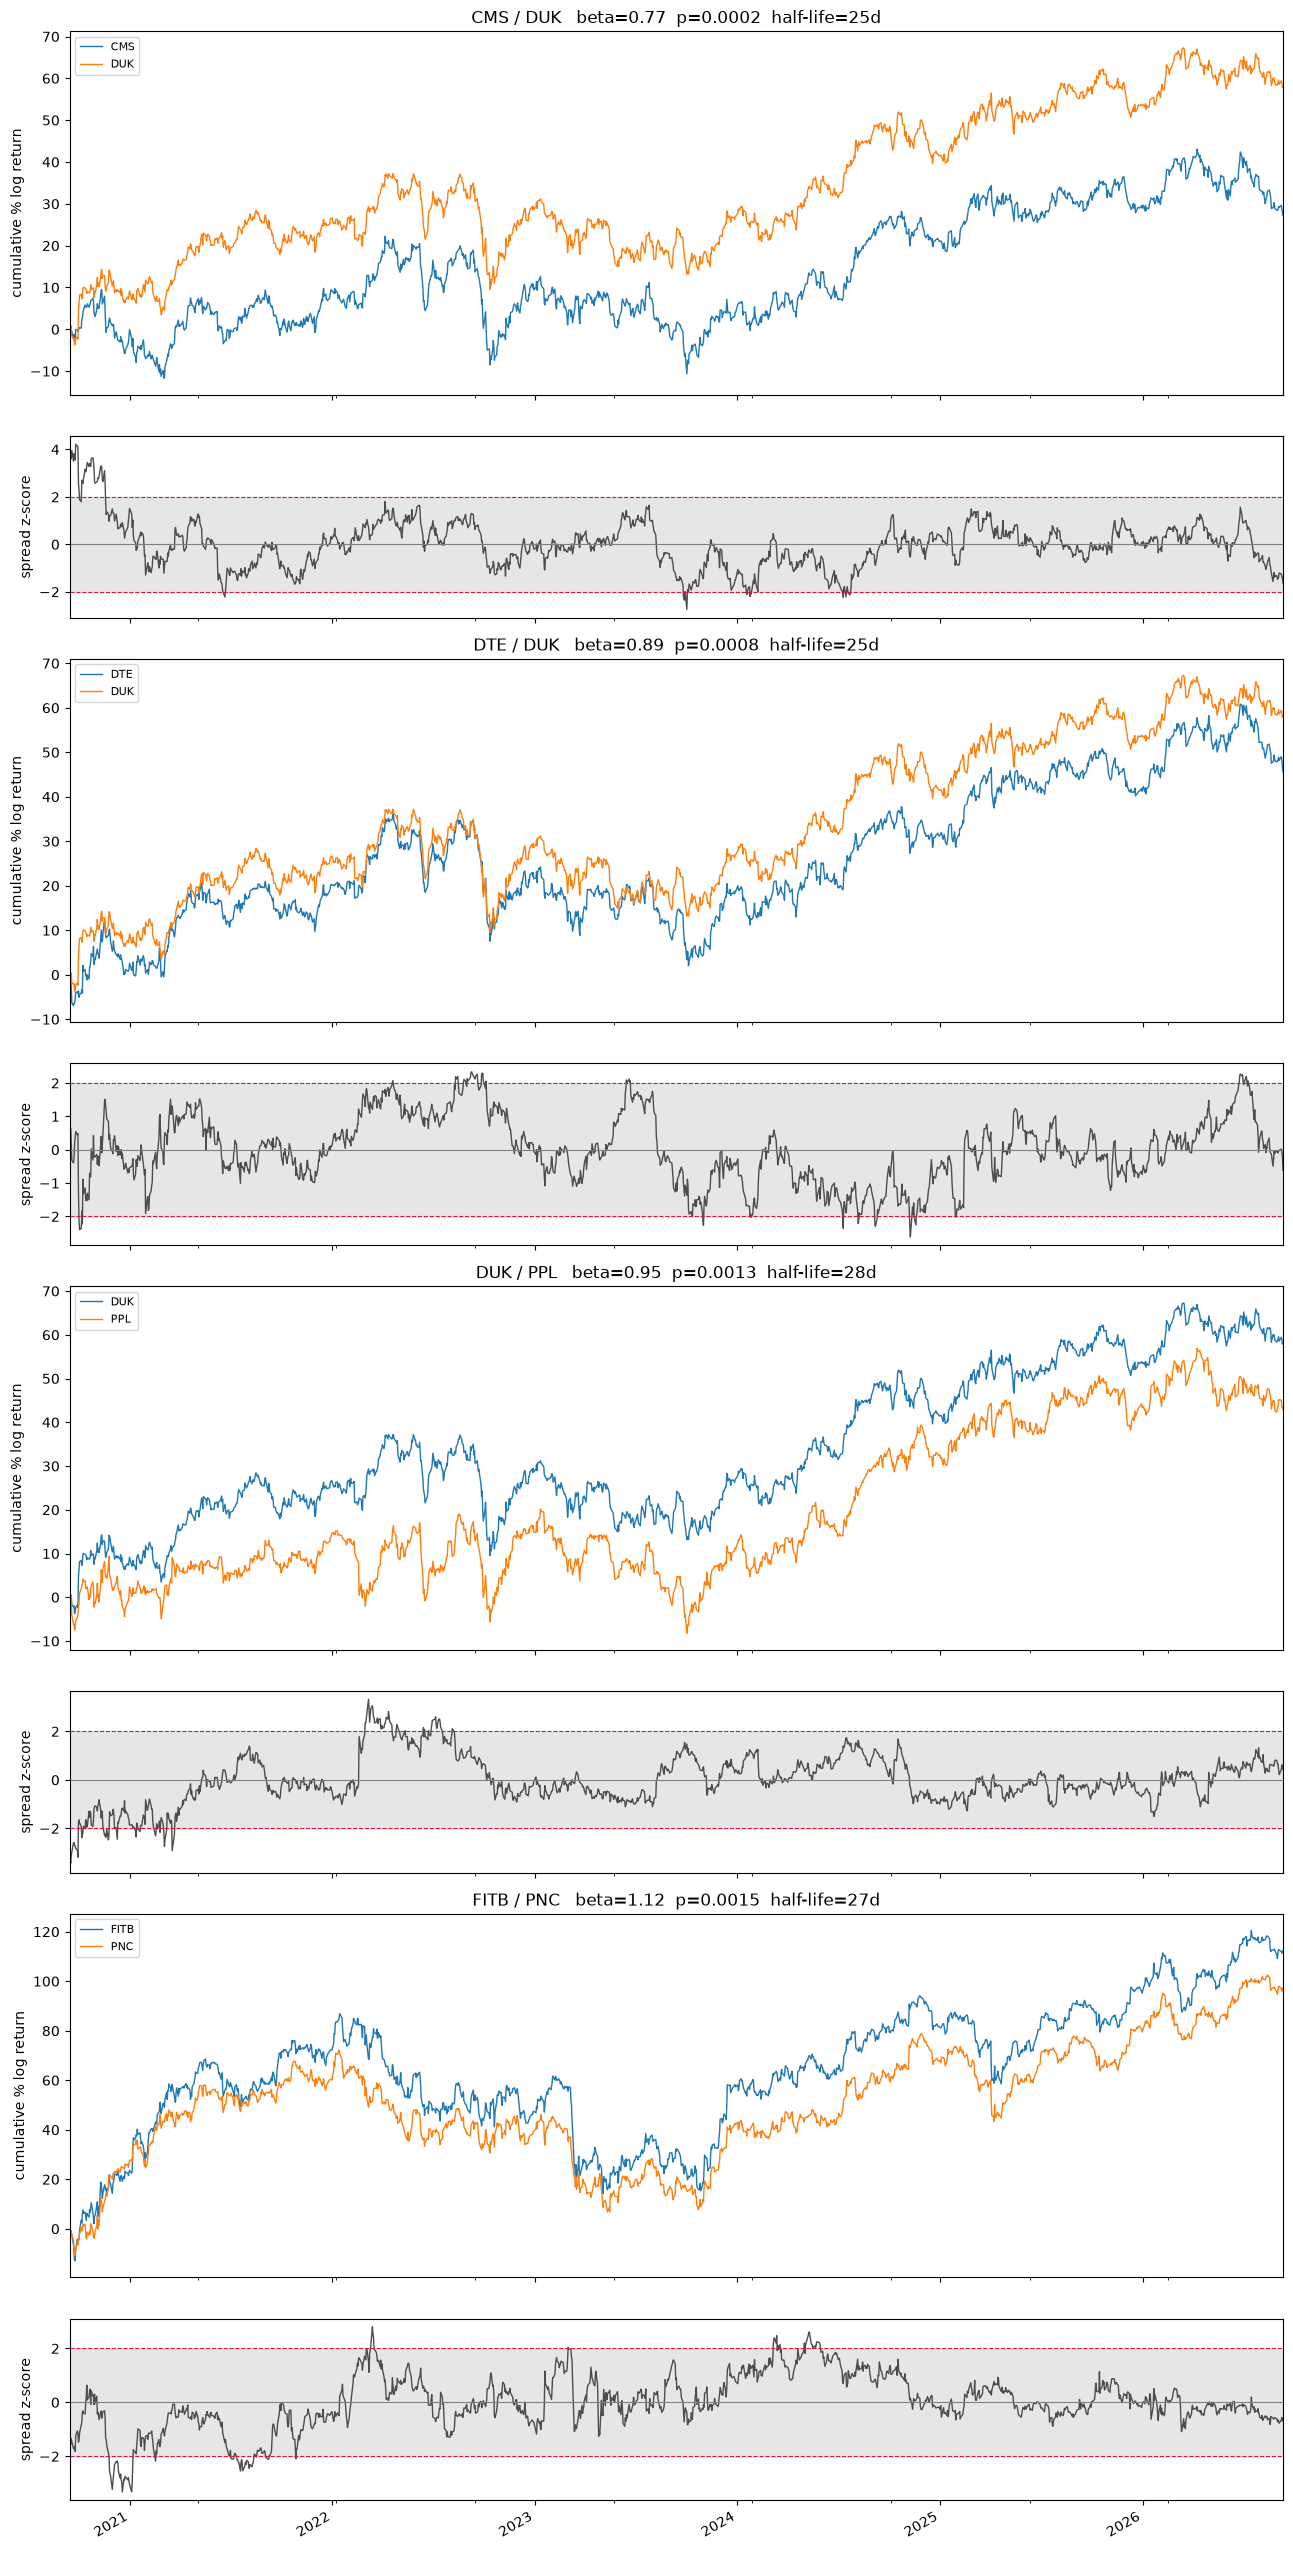

In [95]:
import matplotlib.pyplot as plt


def plot_pair(prices, a, b, metric="close", start=None, end=None, entry=2.0, axes=None):
    """Two panels for one pair: the rebased log legs, and the z-scored spread."""
    wide = prices.pivot(index="date", columns="ticker", values=metric).loc[start:end]
    log_px = np.log(wide[[a, b]].dropna())

    res = engle_granger(log_px[a], log_px[b], check_i1=False)
    spread = res["spread"]
    z = (spread - spread.mean()) / spread.std()

    if axes is None:
        _, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
    top, bot = axes

    (log_px - log_px.iloc[0]).mul(100).plot(ax=top, linewidth=1)
    top.set(ylabel="cumulative % log return")
    top.set_title(f"{a} / {b}   beta={res['beta']:.2f}  "
                  f"p={res['pvalue']:.4f}  half-life={half_life(spread):.0f}d")
    top.legend(fontsize=8)

    z.plot(ax=bot, linewidth=1, color="0.3")
    bot.axhline(0, color="0.5", linewidth=0.8)
    for s in (-entry, entry):
        bot.axhline(s, color="crimson", linestyle="--", linewidth=0.8)
    bot.fill_between(z.index, -entry, entry, color="0.9", zorder=0)
    bot.set(ylabel="spread z-score", xlabel="")
    for ax in axes:
        ax.margins(x=0)
    return axes


# Plot the top cointegrated pairs
top_n = 4
fig, grid = plt.subplots(2 * top_n, 1, figsize=(13, 3.2 * 2 * top_n), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1] * top_n})
for i, row in pairs.head(top_n).iterrows():
    plot_pair(prices, row.a, row.b, axes=grid[2 * i:2 * i + 2])
fig.tight_layout()

In [96]:
# Cointegration is fitted here ...
COINT_START, COINT_END = "2020-09-13", "2025-09-13"
# ... and the spread is monitored here, with those frozen parameters.
MONITOR_START, MONITOR_END = "2025-09-13", "2026-09-13"


def fit_pairs(prices, start=COINT_START, end=COINT_END, corr_min=0.70, alpha=0.01):
    """Run the Engle-Granger screen on the formation window only."""
    return screen_pairs(prices, start=start, end=end, corr_min=corr_min, alpha=alpha)


def monitor(prices, pairs, start=MONITOR_START, end=MONITOR_END, entry=2.0, metric="close"):
    """Z-score each pair's spread over the monitoring window and flag |z| > entry.

    beta, mean and std come from the formation fit, never from the monitoring
    window — that is what makes the z-scores point-in-time valid.
    """
    wide = prices.pivot(index="date", columns="ticker", values=metric)
    form = np.log(wide.loc[COINT_START:COINT_END])
    live = np.log(wide.loc[start:end])

    zs, alerts = {}, []
    for _, p in pairs.iterrows():
        if p.a not in live or p.b not in live:
            continue
        fit = sm.OLS(form[p.a], sm.add_constant(form[p.b])).fit()   # frozen on formation
        mu, sd = fit.resid.mean(), fit.resid.std()

        spread = live[p.a] - fit.params.iloc[0] - fit.params.iloc[1] * live[p.b]
        z = (spread - mu) / sd
        zs[f"{p.a}/{p.b}"] = z

        flags = z[z.abs() > entry]
        if len(flags):
            alerts.append({
                "pair": f"{p.a}/{p.b}", "beta": fit.params.iloc[1],
                "n_days_flagged": len(flags),
                "first_flag": flags.index[0].date(), "max_abs_z": z.abs().max(),
                "z_last": z.iloc[-1],
                "side": "short a / long b" if z.iloc[-1] > 0 else "long a / short b",
            })

    zs = pd.DataFrame(zs)
    alerts = pd.DataFrame(alerts).sort_values("max_abs_z", ascending=False).reset_index(drop=True)
    return zs, alerts

In [97]:
pairs = fit_pairs(prices)          # 17 pairs from 735 candidates

539 tickers, 1256 days -> 730 candidate pairs at corr >= 0.7
17 cointegrated at p < 0.01 (expected by chance alone: 7)


In [99]:
zs, alerts = monitor(prices, pairs)

In [101]:
alerts

,pair,beta,n_days_flagged,first_flag,max_abs_z,z_last,side
0,CAT/URI,0.683377,236,2025-10-02,13.094087,10.332383,short a / long b
1,MCO/SPGI,1.235530,183,2025-10-01,7.105623,5.933704,short a / long b
2,AEP/CMS,1.191567,224,2025-10-02,6.356470,6.356470,short a / long b
3,ADI/KLAC,0.438345,131,2025-10-29,5.436407,3.336847,short a / long b
4,MPWR/NVDA,0.318029,165,2025-10-23,5.350359,2.855229,short a / long b
5,AIG/CB,1.095595,174,2025-11-25,4.650788,-4.267549,long a / short b
6,ADI/MPWR,0.568536,158,2025-10-30,4.597284,4.087368,short a / long b
7,CMS/ETR,0.448367,81,2026-04-29,3.901229,-3.901229,long a / short b
8,ATO/SO,0.988117,199,2025-10-08,3.723842,2.332504,short a / long b
9,TRGP/WMB,1.656639,55,2025-09-19,3.438951,-0.552399,long a / short b


In [102]:
def signals(prices, pairs, start=MONITOR_START, end=MONITOR_END, entry=2.0,
            metric="close", path="signals.csv"):
    """date, short, long — one row per pair per day the spread exceeds +/- entry."""
    wide = prices.pivot(index="date", columns="ticker", values=metric)
    form = np.log(wide.loc[COINT_START:COINT_END])
    live = np.log(wide.loc[start:end])

    rows = []
    for _, p in pairs.iterrows():
        if p.a not in live or p.b not in live:
            continue
        fit = sm.OLS(form[p.a], sm.add_constant(form[p.b])).fit()   # frozen on formation
        spread = live[p.a] - fit.params.iloc[0] - fit.params.iloc[1] * live[p.b]
        z = (spread - fit.resid.mean()) / fit.resid.std()

        hit = z[z.abs() > entry]
        for date, zval in hit.items():
            # z > 0: a is rich relative to b -> short a, long b
            rows.append({"date": date.date(),
                         "short": p.a if zval > 0 else p.b,
                         "long":  p.b if zval > 0 else p.a})

    out = pd.DataFrame(rows, columns=["date", "short", "long"]).sort_values(["date", "short"])
    out.to_csv(path, index=False)
    print(f"{len(out)} signals -> {path}")
    return out

In [103]:
sig = signals(prices, pairs)

1776 signals -> signals.csv
